In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import numpy as np

# Style pour les plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)

In [2]:
def load_and_display_samples(folder, n_samples=5):
    """Affiche des exemples d'images"""
    images = list(Path(folder).glob("*.jpg"))[:n_samples]
    
    fig, axes = plt.subplots(1, n_samples, figsize=(20, 4))
    
    for idx, img_path in enumerate(images):
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title(img_path.stem)
    
    plt.tight_layout()
    plt.show()

Content Images


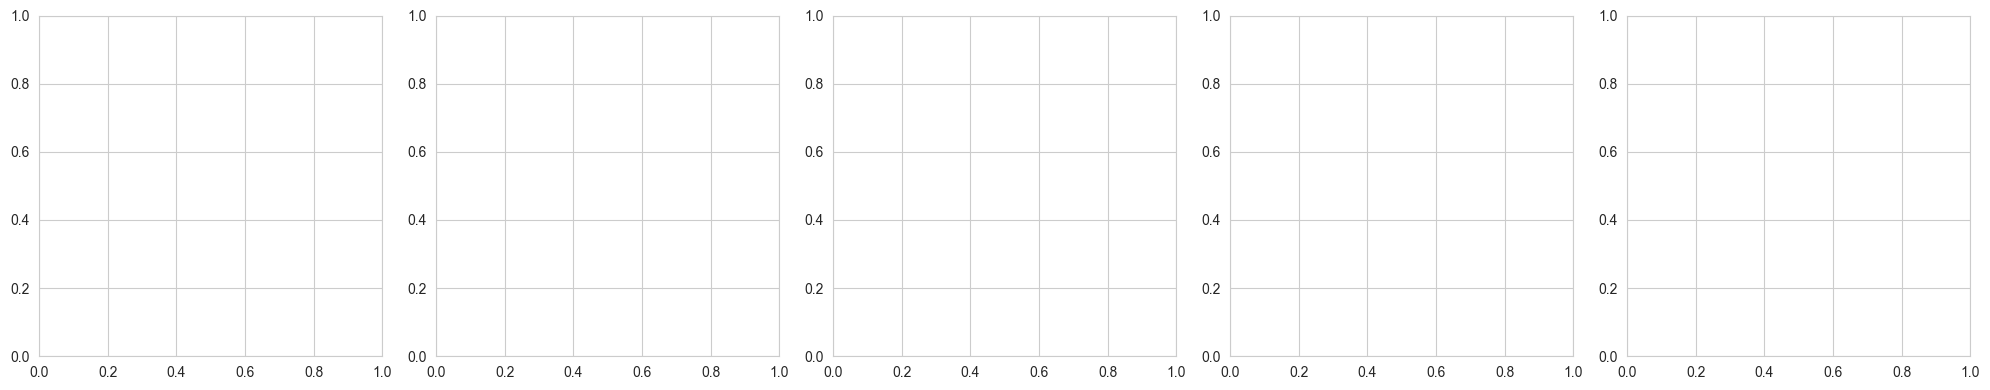

In [3]:
print("Content Images")
load_and_display_samples("data/processed/content", n_samples=5)

Style Images - Impressionism


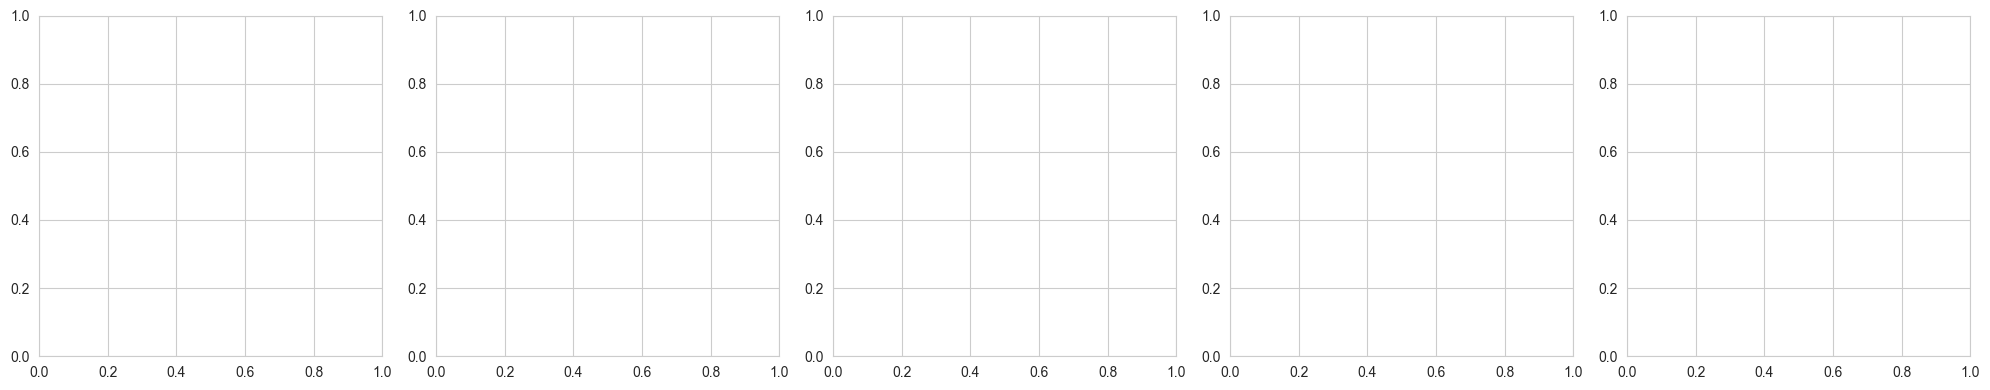

In [4]:
print("Style Images - Impressionism")
load_and_display_samples("data/processed/styles/impressionism", n_samples=5)

In [ ]:
def analyze_image_stats(folder):
    """Analyse statistiques des images"""
    images = list(Path(folder).glob("**/*.jpg"))
    
    widths, heights, sizes = [], [], []
    
    for img_path in images[:1000]:  # Sample
        img = Image.open(img_path)
        widths.append(img.width)
        heights.append(img.height)
        sizes.append(img_path.stat().st_size / 1024)  # KB
    
    print(f"Stats pour {len(images)} images:")
    print(f"Width: {np.mean(widths):.0f}±{np.std(widths):.0f} px")
    print(f"Height: {np.mean(heights):.0f}±{np.std(heights):.0f} px")
    print(f"Size: {np.mean(sizes):.0f}±{np.std(sizes):.0f} KB")
    
    # Histogrammes
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(widths, bins=50, color='skyblue', edgecolor='black')
    axes[0].set_title('Width Distribution')
    axes[1].hist(heights, bins=50, color='salmon', edgecolor='black')
    axes[1].set_title('Height Distribution')
    axes[2].hist(sizes, bins=50, color='lightgreen', edgecolor='black')
    axes[2].set_title('File Size (KB)')
    plt.tight_layout()
    plt.show()

analyze_image_stats("data/processed/content")